# Satellite Image Classification


In [1]:
!pip install -q torchsummary torchview

In [2]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset

import torchvision
from torchvision import transforms, datasets, models

from torchsummary import summary
from torchview import draw_graph
from IPython.display import Image, display

from sklearn.metrics import f1_score, confusion_matrix

from collections import Counter, defaultdict
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [5]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:00<00:00, 264MB/s] 


In [6]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [7]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [8]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

splits = {
    "Train full": train_full,
    "Train 10-shot": train_10shot,
    "Train 5-shot": train_5shot,
    "Validation": val_set,
    "Test": test_set,
}

for name, split in splits.items():
    labels = [label for _, label in split]
    counts = Counter(labels)
    print(f"\n{name}")
    print(f"Total samples: {len(split)}")
    for cls_id, cls_name in enumerate(class_names):
        print(f"    {cls_name}: {counts.get(cls_id, 0)}")


Train full
Total samples: 18900
    AnnualCrop: 2100
    Forest: 2100
    HerbaceousVegetation: 2100
    Highway: 1750
    Industrial: 1750
    Pasture: 1400
    PermanentCrop: 1750
    Residential: 2100
    River: 1750
    SeaLake: 2100

Train 10-shot
Total samples: 100
    AnnualCrop: 10
    Forest: 10
    HerbaceousVegetation: 10
    Highway: 10
    Industrial: 10
    Pasture: 10
    PermanentCrop: 10
    Residential: 10
    River: 10
    SeaLake: 10

Train 5-shot
Total samples: 50
    AnnualCrop: 5
    Forest: 5
    HerbaceousVegetation: 5
    Highway: 5
    Industrial: 5
    Pasture: 5
    PermanentCrop: 5
    Residential: 5
    River: 5
    SeaLake: 5

Validation
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 375
    Industrial: 375
    Pasture: 300
    PermanentCrop: 375
    Residential: 450
    River: 375
    SeaLake: 450

Test
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 

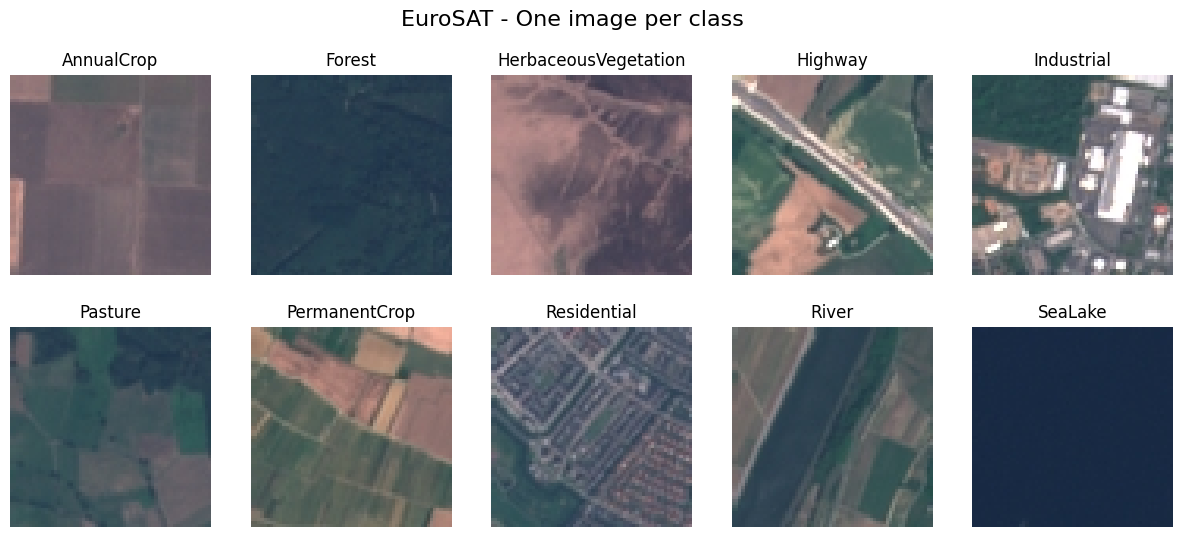

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


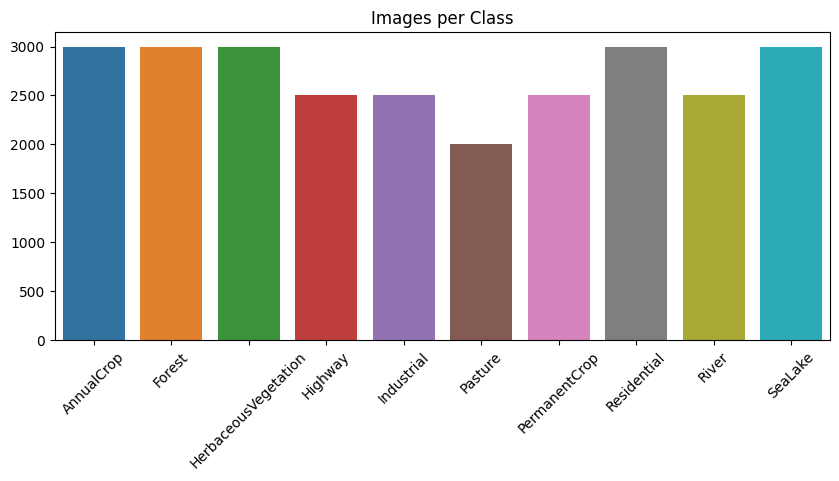

In [10]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

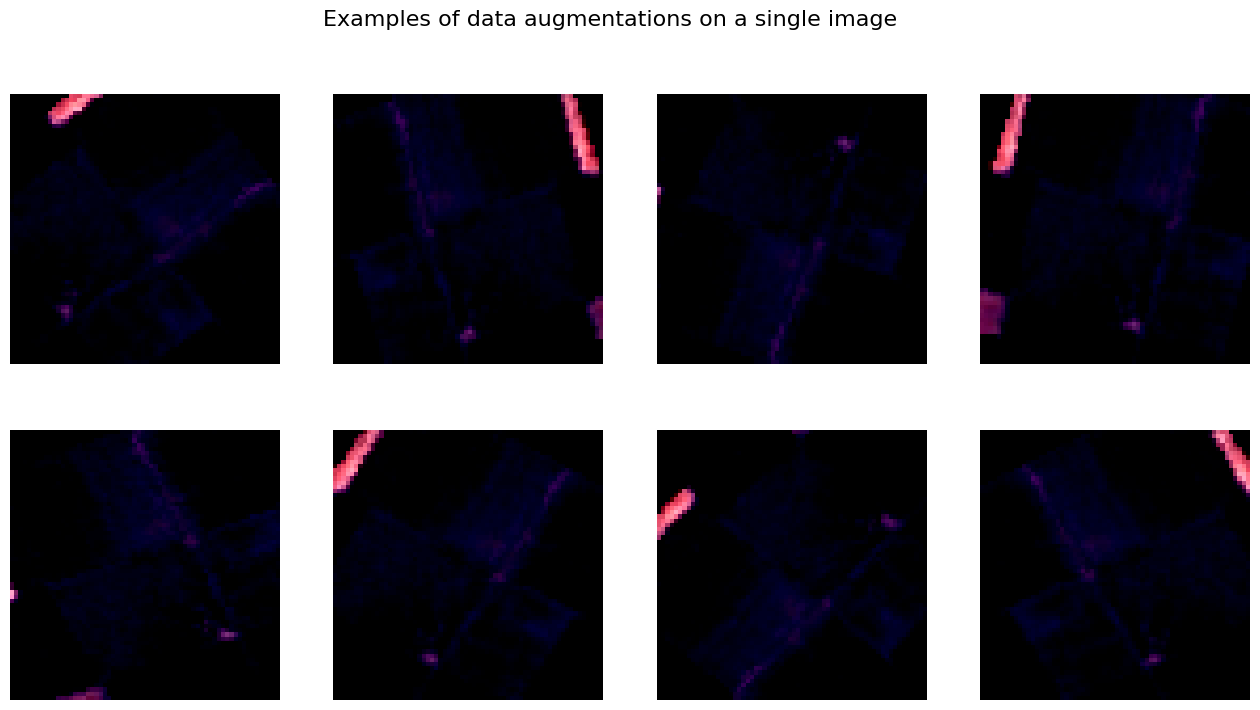

In [11]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()

## 1: Baseline and Transfer Learning


### Task 1.1 - Baseline CNN from scratch


In [12]:
def train_per_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    patience=3,
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(
                f"Early stopping triggered at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }


def plot_train_curves(results, title=""):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss")
    plt.plot(epochs, results["val_losses"], label="Val Loss")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_accs"], label="Train Acc")
    plt.plot(epochs, results["val_accs"], label="Val Acc")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Accuracy Curves - {title}")

    plt.show()

In [13]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)
summary(model, input_size=(3, 64, 64), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
       BatchNorm2d-2           [-1, 32, 64, 64]              64
              ReLU-3           [-1, 32, 64, 64]               0
         MaxPool2d-4           [-1, 32, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          18,496
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
      BatchNorm2d-10          [-1, 128, 16, 16]             256
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
          Flatten-13                 [-1, 8192]               0
           Linear-14                  [

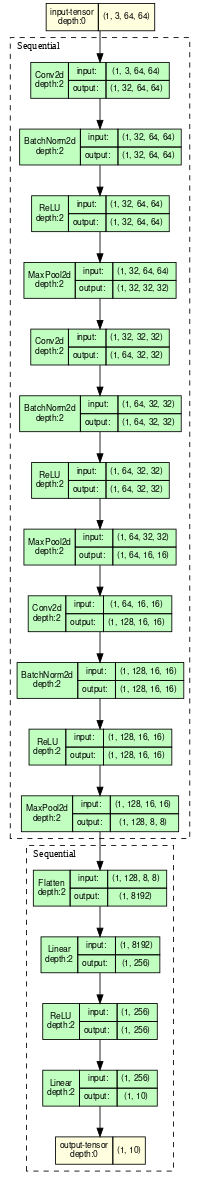

In [14]:
model_graph = draw_graph(
    model, input_size=(1, 3, 64, 64), expand_nested=True, device=device
)
model_graph.visual_graph.render("baseline_cnn", format="png")
display(Image("baseline_cnn.png"))

In [16]:
batch_size = 32

train_loader = DataLoader(
    train_full, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [44]:
reproducibility()
cnn = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

results_cnn = train_model(
    model=cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0501, Train Acc: 0.6241 | Val Loss: 0.8174, Val Acc: 0.6921
Epoch 2/12 | Train Loss: 0.7515, Train Acc: 0.7244 | Val Loss: 0.6353, Val Acc: 0.7864
Epoch 3/12 | Train Loss: 0.6692, Train Acc: 0.7566 | Val Loss: 0.6247, Val Acc: 0.7874
Epoch 4/12 | Train Loss: 0.6042, Train Acc: 0.7838 | Val Loss: 0.5419, Val Acc: 0.8109
Epoch 5/12 | Train Loss: 0.5567, Train Acc: 0.8067 | Val Loss: 0.6433, Val Acc: 0.7916
Epoch 6/12 | Train Loss: 0.5070, Train Acc: 0.8188 | Val Loss: 0.4728, Val Acc: 0.8375
Epoch 7/12 | Train Loss: 0.4704, Train Acc: 0.8335 | Val Loss: 0.4627, Val Acc: 0.8496
Epoch 8/12 | Train Loss: 0.4438, Train Acc: 0.8419 | Val Loss: 0.5344, Val Acc: 0.8405
Epoch 9/12 | Train Loss: 0.4210, Train Acc: 0.8523 | Val Loss: 0.4237, Val Acc: 0.8511
Epoch 10/12 | Train Loss: 0.3933, Train Acc: 0.8606 | Val Loss: 0.3739, Val Acc: 0.8677
Epoch 11/12 | Train Loss: 0.3889, Train Acc: 0.8629 | Val Loss: 0.3433, Val Acc: 0.8805
Epoch 12/12 | Train

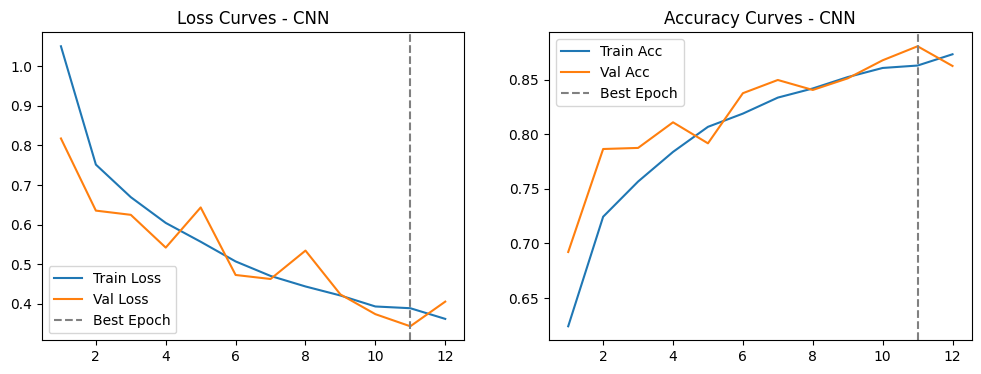

In [45]:
plot_train_curves(results_cnn, "CNN")

### Task 1.2 - Transfer Learning


In [32]:
reproducibility()

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50.parameters(), 1e-3)

results_resnet50 = train_model(
    model=resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.5082, Train Acc: 0.8426 | Val Loss: 0.2661, Val Acc: 0.9202
Epoch 2/15 | Train Loss: 0.3144, Train Acc: 0.9017 | Val Loss: 0.2126, Val Acc: 0.9267
Epoch 3/15 | Train Loss: 0.2626, Train Acc: 0.9128 | Val Loss: 0.1888, Val Acc: 0.9321
Epoch 4/15 | Train Loss: 0.2352, Train Acc: 0.9216 | Val Loss: 0.1727, Val Acc: 0.9425
Epoch 5/15 | Train Loss: 0.2092, Train Acc: 0.9308 | Val Loss: 0.1462, Val Acc: 0.9556
Epoch 6/15 | Train Loss: 0.2058, Train Acc: 0.9319 | Val Loss: 0.1332, Val Acc: 0.9541
Epoch 7/15 | Train Loss: 0.1862, Train Acc: 0.9388 | Val Loss: 0.1423, Val Acc: 0.9533
Epoch 8/15 | Train Loss: 0.1803, Train Acc: 0.9399 | Val Loss: 0.1701, Val Acc: 0.9437
Epoch 9/15 | Train Loss: 0.1773, Train Acc: 0.9420 | Val Loss: 0.3709, Val Acc: 0.8760
Early stopping triggered at epoch 9 (best val loss: 0.1332)
Test Accuracy: 95.21%
Training Time: 6.14 minutes


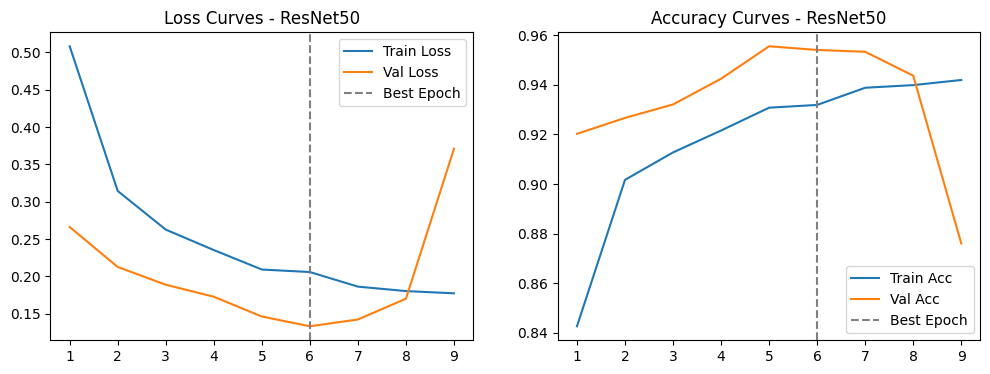

In [38]:
plot_train_curves(results_resnet50, "ResNet50")

In [34]:
reproducibility()

resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50_frozen.parameters(), 1e-3)

results_resnet50_frozen = train_model(
    model=resnet50_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0310, Train Acc: 0.6957 | Val Loss: 0.7348, Val Acc: 0.7812
Epoch 2/12 | Train Loss: 0.7315, Train Acc: 0.7696 | Val Loss: 0.6367, Val Acc: 0.8062
Epoch 3/12 | Train Loss: 0.6719, Train Acc: 0.7833 | Val Loss: 0.5612, Val Acc: 0.8230
Epoch 4/12 | Train Loss: 0.6432, Train Acc: 0.7876 | Val Loss: 0.5696, Val Acc: 0.8165
Epoch 5/12 | Train Loss: 0.6416, Train Acc: 0.7881 | Val Loss: 0.5781, Val Acc: 0.8168
Epoch 6/12 | Train Loss: 0.6288, Train Acc: 0.7963 | Val Loss: 0.5880, Val Acc: 0.8163
Early stopping triggered at epoch 6 (best val loss: 0.5612)
Test Accuracy: 81.80%
Training Time: 2.35 minutes


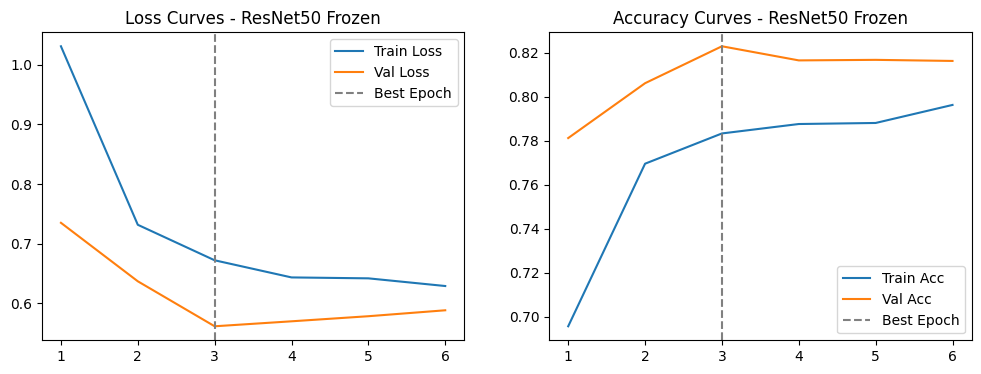

In [35]:
plot_train_curves(results_resnet50_frozen, "ResNet50 Frozen")

In [36]:
reproducibility()

efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0.parameters(), 1e-3)

results_efficientnetb0 = train_model(
    model=efficientnetb0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.5157, Train Acc: 0.8402 | Val Loss: 0.2365, Val Acc: 0.9301
Epoch 2/15 | Train Loss: 0.2721, Train Acc: 0.9133 | Val Loss: 0.2361, Val Acc: 0.9185
Epoch 3/15 | Train Loss: 0.2157, Train Acc: 0.9297 | Val Loss: 0.1989, Val Acc: 0.9252
Epoch 4/15 | Train Loss: 0.1990, Train Acc: 0.9342 | Val Loss: 0.1162, Val Acc: 0.9657
Epoch 5/15 | Train Loss: 0.1761, Train Acc: 0.9423 | Val Loss: 0.1477, Val Acc: 0.9459
Epoch 6/15 | Train Loss: 0.1754, Train Acc: 0.9429 | Val Loss: 0.2102, Val Acc: 0.9316
Epoch 7/15 | Train Loss: 0.1589, Train Acc: 0.9486 | Val Loss: 0.1558, Val Acc: 0.9528
Early stopping triggered at epoch 7 (best val loss: 0.1162)
Test Accuracy: 95.88%
Training Time: 4.29 minutes


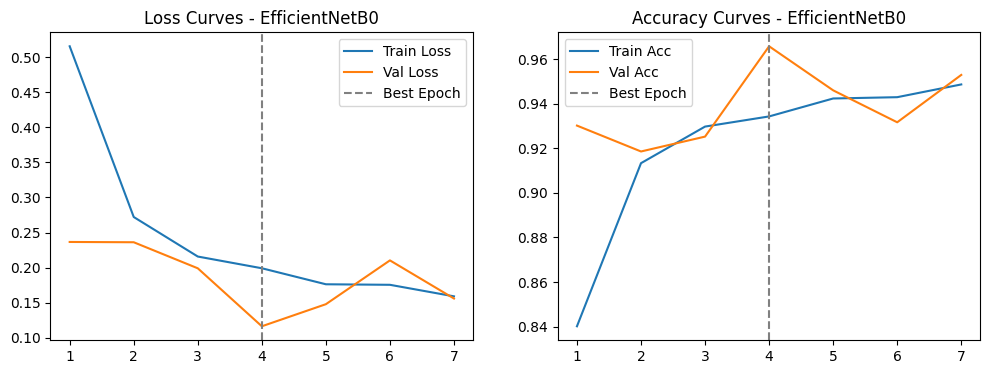

In [37]:
plot_train_curves(results_efficientnetb0, "EfficientNetB0")

In [39]:
reproducibility()

efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_frozen.parameters(), 1e-3)

results_efficientnetb0_frozen = train_model(
    model=efficientnetb0_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 1.0265, Train Acc: 0.6610 | Val Loss: 0.8521, Val Acc: 0.7183
Epoch 2/15 | Train Loss: 0.8639, Train Acc: 0.7093 | Val Loss: 0.7913, Val Acc: 0.7363
Epoch 3/15 | Train Loss: 0.8459, Train Acc: 0.7132 | Val Loss: 0.8002, Val Acc: 0.7291
Epoch 4/15 | Train Loss: 0.8514, Train Acc: 0.7096 | Val Loss: 0.8117, Val Acc: 0.7259
Epoch 5/15 | Train Loss: 0.8451, Train Acc: 0.7143 | Val Loss: 0.7859, Val Acc: 0.7378
Epoch 6/15 | Train Loss: 0.8481, Train Acc: 0.7142 | Val Loss: 0.7899, Val Acc: 0.7368
Epoch 7/15 | Train Loss: 0.8473, Train Acc: 0.7158 | Val Loss: 0.8022, Val Acc: 0.7333
Epoch 8/15 | Train Loss: 0.8479, Train Acc: 0.7134 | Val Loss: 0.7828, Val Acc: 0.7375
Epoch 9/15 | Train Loss: 0.8505, Train Acc: 0.7147 | Val Loss: 0.7830, Val Acc: 0.7363
Epoch 10/15 | Train Loss: 0.8531, Train Acc: 0.7127 | Val Loss: 0.7961, Val Acc: 0.7316
Epoch 11/15 | Train Loss: 0.8639, Train Acc: 0.7093 | Val Loss: 0.7841, Val Acc: 0.7388
Early stopping trig

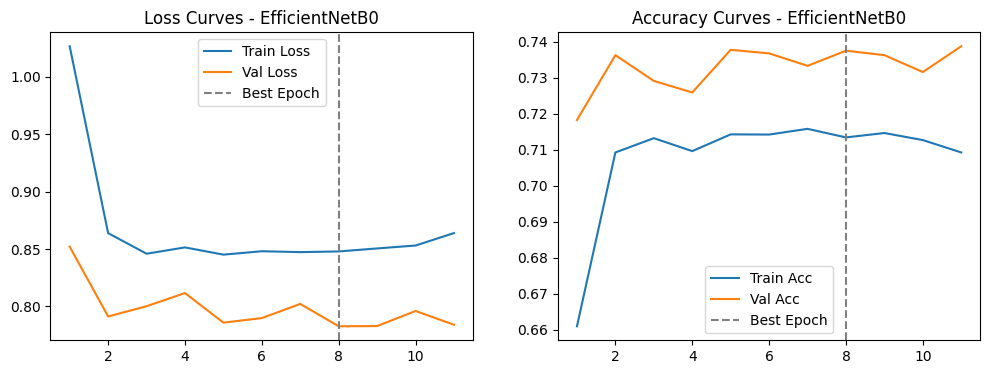

In [40]:
plot_train_curves(results_efficientnetb0_frozen, "EfficientNetB0")

In [19]:
train_transform_vit = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_full_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_full_idx,
)
val_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    val_idx,
)
test_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    test_idx,
)

batch_size_vit = 32

train_loader_vit = DataLoader(
    train_full_vit, batch_size=batch_size_vit, shuffle=True, num_workers=4
)
val_loader_vit = DataLoader(
    val_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=4
)
test_loader_vit = DataLoader(
    test_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=4
)

In [20]:
reproducibility()

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, num_classes)
vit = vit.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit.parameters(), 3e-4)

results_vit = train_model(
    model=vit,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4433, Train Acc: 0.8486 | Val Loss: 0.3301, Val Acc: 0.8970
Epoch 2/15 | Train Loss: 0.2428, Train Acc: 0.9171 | Val Loss: 0.2201, Val Acc: 0.9183
Epoch 3/15 | Train Loss: 0.2086, Train Acc: 0.9295 | Val Loss: 0.1534, Val Acc: 0.9499
Epoch 4/15 | Train Loss: 0.1852, Train Acc: 0.9358 | Val Loss: 0.1318, Val Acc: 0.9533
Epoch 5/15 | Train Loss: 0.1616, Train Acc: 0.9458 | Val Loss: 0.2065, Val Acc: 0.9301
Epoch 6/15 | Train Loss: 0.1592, Train Acc: 0.9462 | Val Loss: 0.1224, Val Acc: 0.9588
Epoch 7/15 | Train Loss: 0.1464, Train Acc: 0.9498 | Val Loss: 0.1233, Val Acc: 0.9595
Epoch 8/15 | Train Loss: 0.1389, Train Acc: 0.9515 | Val Loss: 0.2497, Val Acc: 0.9205
Epoch 9/15 | Train Loss: 0.1411, Train Acc: 0.9525 | Val Loss: 0.1302, Val Acc: 0.9563
Early stopping triggered at epoch 9 (best val loss: 0.1224)
Test Accuracy: 95.43%
Training Time: 119.61 minutes


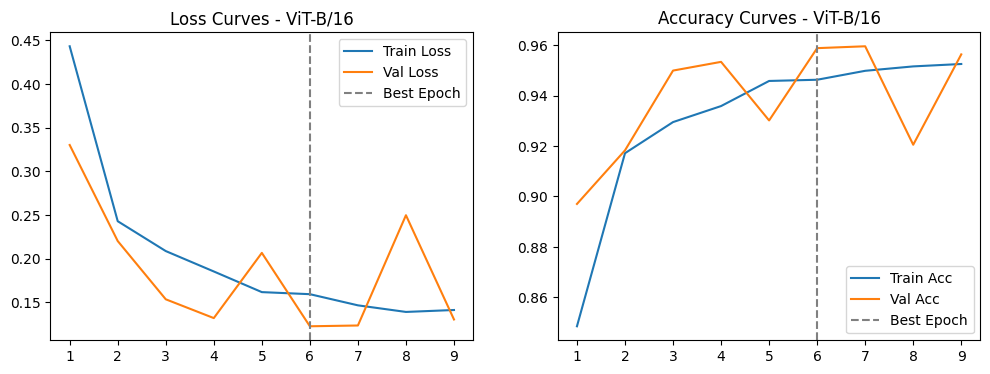

In [21]:
plot_train_curves(results_vit, "ViT-B/16")